<a href="https://colab.research.google.com/github/anushkarajora11/Data2Detect-ACA/blob/main/mid_termQuestion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mid-Term Assignment

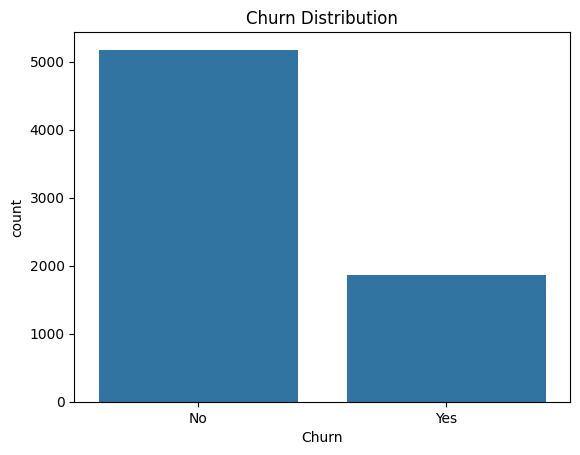

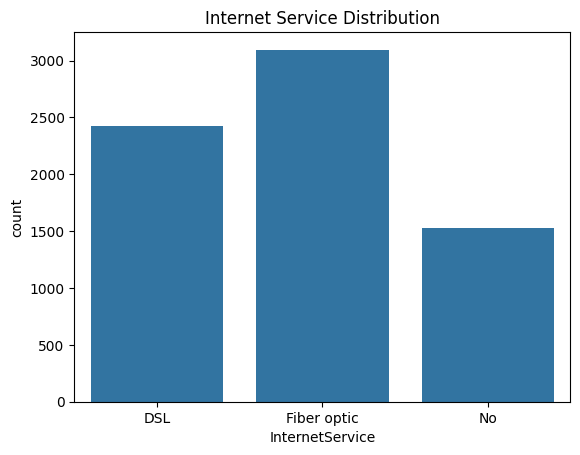

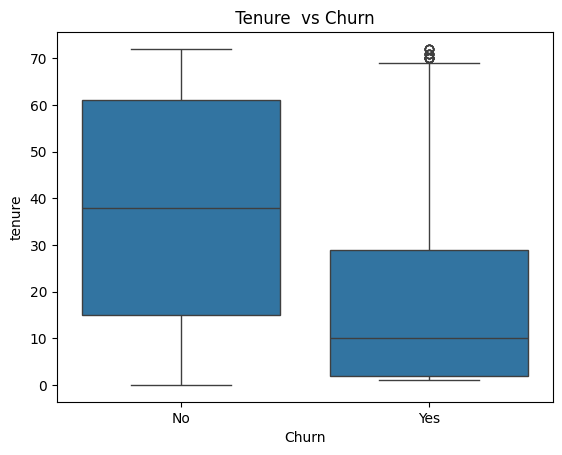

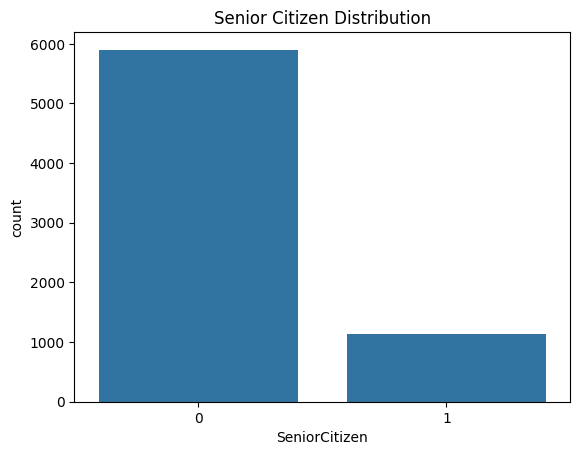

In [ ]:
#Question 1
# Part 1)  Load the Telco Customer Churn Dataset.
# Part 2) Perform Exploratory Data Analysis (EDA) to understand feature distributions, outliers,
#         and relationships.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/Telco-Customer-Churn.csv')
data.head()
# EDA
data.info
data.describe
data.isnull().sum
data['Churn'].value_counts()

sns.countplot(x='Churn', data=data)
plt.title('Churn Distribution')
plt.show()

sns.countplot(x='InternetService', data=data)
plt.title('Internet Service Distribution')
plt.show()

sns.boxplot(x='Churn', y = 'tenure' , data=data)
plt.title(' Tenure  vs Churn ')
plt.show()

sns.countplot(x='SeniorCitizen', data=data)
plt.title('Senior Citizen Distribution')
plt.show()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


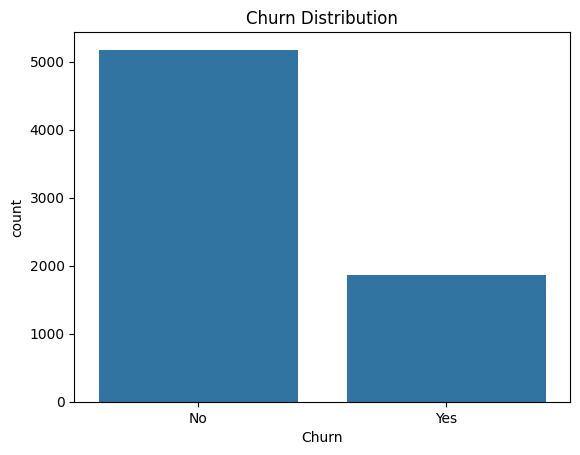

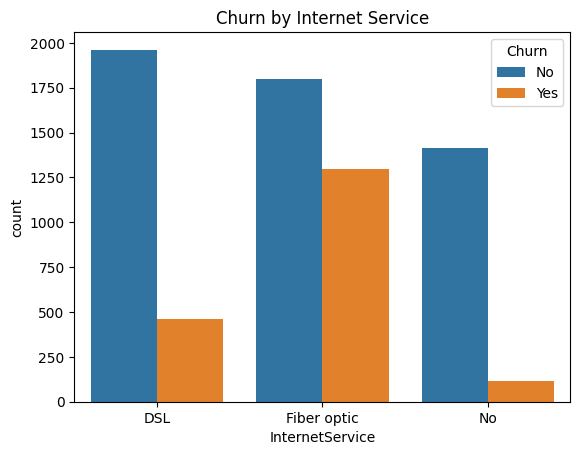

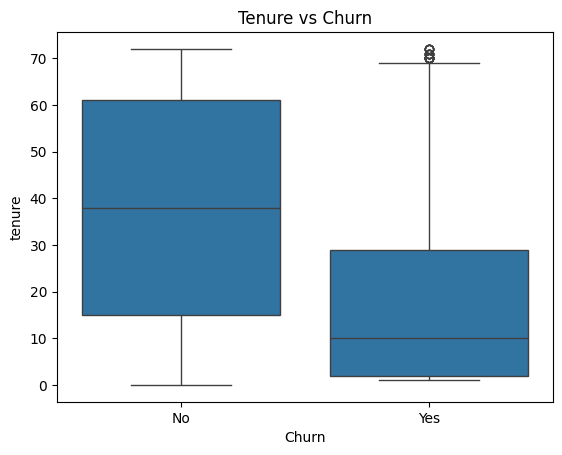

ValueError: could not convert string to float: 'No phone service'

In [ ]:

# Question 1
# Part 3) 4) 5)Implement any necessary preprocessing and feature transformations.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

data = pd.read_csv('/content/Telco-Customer-Churn.csv')

print(data.info())
print(data.describe())
print(data['Churn'].value_counts())

sns.countplot(data=data, x='Churn')
plt.title('Churn Distribution')
plt.show()

sns.countplot(data=data, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.show()


data.drop('customerID', axis=1, inplace=True)

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

data.dropna(inplace=True)


categorical_cols = data.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')

le = LabelEncoder()
binary_cols = [col for col in categorical_cols if data[col].nunique() == 2]
for col in binary_cols:
    data[col] = le.fit_transform(data[col])


data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})


scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])


X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


from sklearn.metrics import RocCurveDisplay

for name, model in models.items():
    print(f"----{name}----")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)

plt.title('ROC Curve Comparison')
plt.show()